# Analysis 3: Formulation of DPA

Before you proceed this workflow, I encourage you to follow the tutorials on ```00_tutorials/``` folder prior programming to have everything downloaded.

In this workflow, we will be predicting a potential formulation of DPA considering chemical properties.

Make sure you already have installed ```pubchempy```, ```matplotlib```, ```rdkit```, ```py3dmol``` libraries. Otherwise, copy the following lines and paste it on the terminal:

1. ```conda activate vina```
2. ```sudo apt install openbabel```
3. ```conda install matplotlib rdkit pubchempy py3Dmol```

# 1. Retrieve general information from DPA

In [ ]:
# Cell 1: Fetch compound details
import pubchempy as pcp

# Fetch compound details using CID
cid = 10367
compound = pcp.Compound.from_cid(cid)

dpa_smiles = compound.isomeric_smiles # Change if Ca+ is needed
print(f"Name: {compound.iupac_name}")
print(f"SMILES: {dpa_smiles}")
print(f"Molecular Weight: {compound.molecular_weight:.2f} g/mol")
print(f"Formula: {compound.molecular_formula}")

Name: pyridine-2,6-dicarboxylic acid
SMILES: C1=CC(=NC(=C1)C(=O)O)C(=O)O
Molecular Weight: 167.12 g/mol
Formula: C7H5NO4


/tmp/ipykernel_36620/2906849140.py:8: PubChemPyDeprecationWarning: isomeric_smiles is deprecated: Use smiles instead
  dpa_smiles = compound.isomeric_smiles


# 2. 3D Molecular Modeling & Conformational Energy

In [29]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import IPythonConsole

# Create and optimize 3D molecule
mol = Chem.MolFromSmiles(dpa_smiles)
mol_h = Chem.AddHs(mol) 
AllChem.EmbedMolecule(mol_h, AllChem.ETKDG())
AllChem.MMFFOptimizeMolecule(mol_h)

# Energy Calculation
ff_props = AllChem.MMFFGetMoleculeProperties(mol_h)
ff = AllChem.MMFFGetMoleculeForceField(mol_h, ff_props)
energy = ff.CalcEnergy()

print(f"MMFF94 Internal Potential Energy: {energy:.2f} kcal/mol")
print("Note: Higher energy suggests potential for stabilization via solvent interactions.")

MMFF94 Internal Potential Energy: 66.48 kcal/mol
Note: Higher energy suggests potential for stabilization via solvent interactions.


Visualize 2D structure

2D Structure of Dipicolinic Acid:


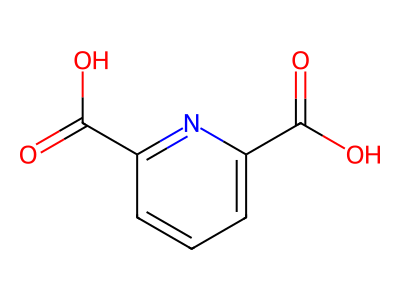

In [30]:
print("2D Structure of Dipicolinic Acid:")
img = Draw.MolToImage(mol, size=(400, 300))
display(img)

In [31]:
import py3Dmol

print("\n3D Structure (rotate and zoom with mouse):")
view = py3Dmol.view(width=400, height=300)
view.addModel(Chem.MolToMolBlock(mol_h), 'mol')
view.setStyle({'stick': {'colorscheme': 'lightgreyCarbon'}})
view.addSurface(py3Dmol.SAS, {'opacity': 0.7, 'color': 'lightblue'})
view.zoomTo()
view.show()


3D Structure (rotate and zoom with mouse):


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# 3. Calculate basic molecular properties

In [ ]:
from rdkit.Chem import Descriptors

# Calculate key properties
logp = Descriptors.MolLogP(mol)
tpsa = Descriptors.TPSA(mol)
mw = Descriptors.MolWt(mol)
hbd = Descriptors.NumHDonors(mol)
hba = Descriptors.NumHAcceptors(mol)

# Create a property summary dictionary
properties = {
    "LogP (Partition Coefficient)": f"{logp:.3f}",
    "Topological Polar Surface Area": f"{tpsa:.2f} Å²",
    "Molecular Weight": f"{mw:.2f} g/mol",
    "Hydrogen Bond Donors": f"{hbd}",
    "Hydrogen Bond Acceptors": f"{hba}",
    "Rotatable Bonds": f"{Descriptors.NumRotatableBonds(mol)}"
}

print("MOLECULAR PROPERTIES SUMMARY:")
print("=" * 50)
for prop, value in properties.items():
    print(f"{prop:<35}: {value}")

print("\n" + "=" * 50)
print("SOLVENT AFFINITY PREDICTION:")
print("-" * 50)

if logp < 0:
    print("\t- Prediction: Higher stability/solubility in Water")
    print("\t- Reason: Negative LogP indicates hydrophilic character")
else:
    print("\t- Prediction: Higher stability/solubility in Lipid environments")
    print("\t- Reason: Positive LogP indicates lipophilic character")

if tpsa > 60:
    print(f"High Polar Surface Area ({tpsa:.1f} Å²):")
    print("\t- Significant hydrogen bonding capability")
    print("\t- Good aqueous solubility expected")
    print("\t- Poor membrane permeability predicted")

MOLECULAR PROPERTIES SUMMARY:
LogP (Partition Coefficient)       : 0.478
Topological Polar Surface Area     : 87.49 Å²
Molecular Weight                   : 167.12 g/mol
Hydrogen Bond Donors               : 2
Hydrogen Bond Acceptors            : 3
Rotatable Bonds                    : 2

SOLVENT AFFINITY PREDICTION:
--------------------------------------------------
	- Prediction: Higher stability/solubility in Lipid environments
	- Reason: Positive LogP indicates lipophilic character
High Polar Surface Area (87.5 Å²):
	- Significant hydrogen bonding capability
	- Good aqueous solubility expected
	- Poor membrane permeability predicted


# 4. pH-Dependent Stability Analysis (LogD Curve)

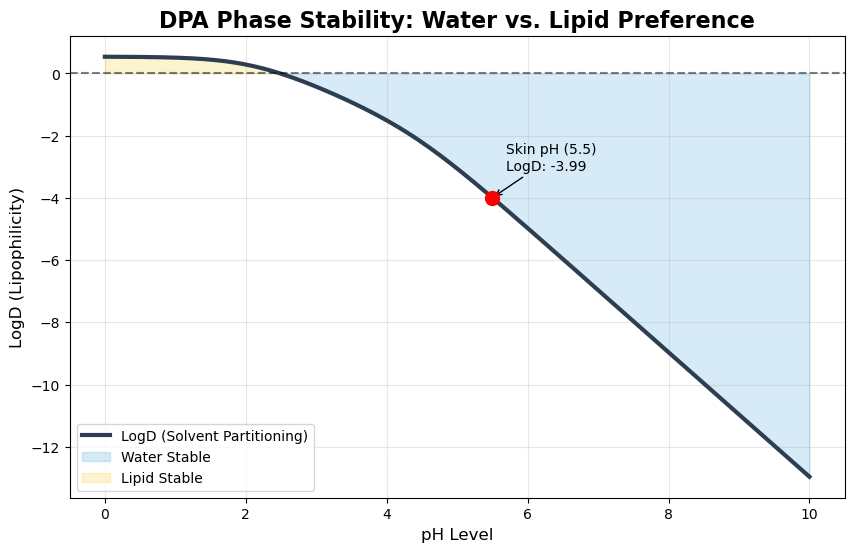

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_logd(logp, pka1, pka2, ph):
    # LogD formula for a diprotic acid
    correction = np.log10(1 + 10**(ph - pka1) + 10**(2*ph - pka1 - pka2))
    return logp - correction

# Parameters (PubChem Data)
pka1, pka2 = 2.1, 4.4
logp_val = 0.54  
ph_range = np.linspace(0, 10, 200)
logd_range = [calculate_logd(logp_val, pka1, pka2, p) for p in ph_range]

# Plotting for presentation
plt.figure(figsize=(10, 6))
plt.plot(ph_range, logd_range, color='#2c3e50', linewidth=3, label='LogD (Solvent Partitioning)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# Highlighting regions
plt.fill_between(ph_range, logd_range, 0, where=(np.array(logd_range) < 0), color='#3498db', alpha=0.2, label='Water Stable')
plt.fill_between(ph_range, logd_range, 0, where=(np.array(logd_range) >= 0), color='#f1c40f', alpha=0.2, label='Lipid Stable')

# Mark Skin pH
skin_ph = 5.5
skin_logd = calculate_logd(logp_val, pka1, pka2, skin_ph)
plt.scatter(skin_ph, skin_logd, color='red', s=100, zorder=5)
plt.annotate(f'Skin pH (5.5)\nLogD: {skin_logd:.2f}', (skin_ph, skin_logd), xytext=(10, 20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

plt.title('DPA Phase Stability: Water vs. Lipid Preference', fontsize=16, fontweight='bold')
plt.xlabel('pH Level', fontsize=12)
plt.ylabel('LogD (Lipophilicity)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 5. Summary

```
FORMULATION STRATEGY
==============================
1. STABILITY: DPA is extremely stable in aqueous (water) phases at skin pH.
2. SOLUBILITY: A lipid-only base is unsuitable due to high LogD and TPSA penalty.
3. Conclusions: 'O/W' emulsion formulation since DPA acts as a water-phase booster for UVC/UVB protection, paired with lipid-phase UVA filters.
``` 